In [3]:
from IPython.display import clear_output
from matplotlib import cm, colors
import numpy as np
from numpy import pi
from scipy.optimize import fsolve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import tqdm
# ===================== Geometry =====================

L_b = 0.3185						# beam length [m]
w_p = 10e-3						# patch width [m]
w_s = 0.265625e-3					# spacing between patches [m]
Q = 31								# number of unit cells
S = Q								# one patch per cell
# positions

xL = np.array([(j-1)*w_p + j*w_s for j in range(1, S+1)], dtype=float)
xR = xL + w_p
eps0 = 8.854e-12
eps_r = 1900.0

d31 = -1.75e-10
s11 = 1.5873e-11
e31 = d31 / s11   
# print(f"e31ff = {e31:e} C/m^2")
eps33_bar = eps0 * eps_r
eps33 = eps33_bar - d31**2 / s11
# print(f"eps33_bar = {eps33_bar:e} F/m")

#  ===================== Beam material (6061 Al) =====================
rho_p, rho_s = 8500, 2700          # [kg/m³]
E_p, E_s   = 1/s11, 70e9           # [Pa]						# Pa
b = 10e-3						# m
hp, hs = 0.23e-3, 0.5e-3 					# m
hpc = (hp + hs)/2
#===================================Stiffness==========================
m = b*(rho_s * hs + 2 * rho_p * hp)
term1 = E_s * hs**3 / 8
term2 = E_p * ((hp + hs/2)**3 - hs**3/8)
YI = 2*b/3 * (term1 + term2)
# e31 = -14.76 #-5.4e-10						# C/m^2 (typical for PZT-5A)
# e31, eps33 = -14.76, 14.8e-9   

# A_term = (hp + 0.5*hs)**2 - (hs**2)/4.0
Cp_scalar = 2*eps33*  w_p * b / hp
Cp = Cp_scalar * np.ones(S)
theta_mech = 2*e31 * b *hpc		# parallel case (3.9)

# ===================== Piezo capacitance =====================



# ===================== Cantilever eigenvalues =====================

N = 40							# number of modes

def eigen_eq(lam):
	return 1.0 + np.cos(lam)*np.cosh(lam)

def lambda_(i):
	lam0 = np.pi*(i+0.5)
	return fsolve(eigen_eq, lam0)[0]

lambda_vals = np.array([lambda_(i) for i in range(N)], dtype=float)

beta = lambda_vals / L_b
omega = beta**2 * np.sqrt(YI / m)

# Rayleigh damping = 1% per mode approx (adjust if needed)


# ===================== Mass-normalized mode shapes (your eq. 2.10) =====================
def stable_exp_term(lam, x):
    num = np.sin(lam) + np.cos(lam) + np.exp(-lam)
    den = np.cos(lam)*np.exp(-lam) + 0.5 + 0.5*np.exp(-2*lam)
    return 1/2*(num / den) * np.exp(lam*(x/L_b - 1.0))

def sigma_r(lam):
    num = 2*np.sin(lam)*np.exp(-lam) - 1 + np.exp(-2*lam)
    den = 2*np.cos(lam)*np.exp(-lam) + 1 + np.exp(-2*lam)
    return num / den
# sigma_vals = np.array([sigma_r(r) for r in range(N)], dtype=float)
sigma_vals = np.array([sigma_r(lambda_vals[r]) for r in range(N)], dtype=float)

def mode_shape(r, x):
    lam   = lambda_vals[r]
    sigma = sigma_vals[r]
    x = np.asarray(x)

    term = stable_exp_term(lam, x)

    phi = (
        np.cos(lam*x/L_b)
        + sigma*np.sin(lam*x/L_b)
        - term
        - 1/2*(1-sigma)*np.exp( -lam*x/L_b )
    )
    return np.sqrt(1/(m*L_b)) * phi

def mode_shape_dx(r, x):
    lam   = lambda_vals[r]
    sigma = sigma_vals[r]
    x = np.asarray(x)

    theta = lam*x/L_b

    # the stabilized exponential growth term
    term = stable_exp_term(lam, x)
    term_dx = term * (lam/L_b)

    # derivative of the final (1-sigma)/2 * exp(-lam x / L)
    last_exp = 0.5*(1 - sigma) * np.exp(-lam*x/L_b)
    last_exp_dx = -last_exp * (lam/L_b)

    # assemble phi_x
    phi_x = (
        -np.sin(theta) * (lam/L_b)
        + sigma*np.cos(theta) * (lam/L_b)
        - term_dx
        - last_exp_dx
    )

    return np.sqrt(1/(m*L_b)) * phi_x





# ===================== Forcing integral (your eq. 2.24) =====================

Phi_int = np.zeros(N)
for r in range(N):
	lam = lambda_vals[r]
	sigma = sigma_vals[r]
	Phi_int[r] = (2 * sigma / lam) * np.sqrt(L_b / m)

# ===================== Coupling matrix =====================

Gamma = np.zeros((N, S))
for r in range(N):
	for j in range(S):
		Gamma[r, j] = mode_shape_dx(r, xR[j]) - mode_shape_dx(r, xL[j])

# ===================== Base excitation: chirp 1–5 kHz =====================

j_exc =30
A_exc = 50
f0 = 1e3
f1 = 1.5e3
t_end = 0.1

def v_exc(t, A_exc=A_exc, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)

# ===================== Duffing shunt parameters (all set to 1) =====================

R_b = 1e6
R_c = 1e3

zeta_p = 0.0151
zeta_q = 0.0392
omega_p = 2*np.pi*1070
omega_q = 2*np.pi*5892.5 
A = np.array([
	[omega_p/(2*YI), 1/(2*m*omega_p)],
	[omega_q/(2*YI), 1/(2*m*omega_q)]
])
b = np.array([zeta_p, zeta_q])
c_beta, c_alpha = np.linalg.solve(A, b)
print("C_beta  =", c_beta)
print("C_alpha =", c_alpha)

# zeta = 0.003 * np.ones(N)
zeta = c_alpha / (2*omega*m) + c_beta * omega / (2*YI)
# zete = 
omega2 = omega**2
damp = 2*zeta*omega
# damp = 2*0.029 * np.ones(N)

def odefun(t, x, v_exc=v_exc, K_c=0, K_p=0, K_i=0):
	eta = x[0:N]
	eta_dot = x[N:2*N]
	z = x[2*N:2*N+S]
	v = x[2*N+S:2*N+2*S]
	v[j_exc] = v_exc(t)
	# mechanical
	eta_ddot = - damp*eta_dot - omega2*eta + theta_mech*(Gamma @ v)
	# voltage equation (replaces Y*v term with Kp*v + Ki*z)
	v_dot = np.zeros(S)
	z_dot = np.zeros(S)
	strain_coupling = Gamma.T @ eta_dot
	# nonlinear Duffing term: Kc * z^3
	duffing = z**3
	# voltage ODE
	num = -(K_p/R_c * v) - (K_i/R_c * z) - theta_mech * strain_coupling - (K_c/R_c * duffing)
	v_dot =  num / Cp	# integrator state
	z_dot = v
	# override voltage directly
	# v[j_exc] = v_exc(t)
	# v_dot[j_exc] = 0.0
	# z_dot[j_exc] = v_exc(t)
		
	return np.concatenate([eta_dot, eta_ddot, v, v_dot])

# ===================== Solve =====================


def modal_simulation(K_c = 0, K_p = 0.00, K_i = 0):
    def f_eval(x):
        return odefun(0, x, v_exc=lambda t: 0, K_c=K_c, K_p=K_p, K_i=K_i)   # freeze excitation

    # M = 2                   # number of samples
    # eps = 1e-1                 # perturbation radius around equilibrium
    dim = 2*N + 2*S
    # X = eps * (2*np.random.rand(dim, M) - 1)
    # Y = np.zeros((dim, M))
    # for k in range(M):
    #     Y[:, k] = f_eval(X[:, k])

    A12 = np.eye(N)
    A21 = -np.diag(omega2)
    A22 = -np.diag(damp)
    A24 = theta_mech*Gamma
    A34 = np.eye(S)
    A42 = -(theta_mech/Cp_scalar)*Gamma.T
    A43 = -np.eye(S)*K_i/R_c/Cp_scalar
    A44 = -np.eye(S)*K_p/R_c/Cp_scalar
    A = np.zeros((dim, dim))
    A[0:N, N:2*N] = A12
    A[N:2*N, 0:N] = A21
    A[N:2*N, N:2*N] = A22
    A[N:2*N, 2*N+S:2*N+2*S] = A24
    A[2*N:2*N+S, 2*N+S:2*N+2*S] = A34
    A[2*N+S:2*N+2*S, N:2*N] = A42
    A[2*N+S:2*N+2*S, 2*N:2*N+S] = A43
    A[2*N+S:2*N+2*S, 2*N+S:2*N+2*S] = A44
    A[N:2*N, 2*N + j_exc] = 0.0   # THIS IS YOUR HANDWRITTEN RULE
    # Y_anl = A @ X
    # # Error between analytical linearization and sampled data
    # residual = Y - Y_anl
    # abs_err_norm = np.linalg.norm(residual)
    # rel_err_norm = abs_err_norm / (np.linalg.norm(Y))
    # per_sample_rel_err = np.linalg.norm(residual, axis=0) / (np.linalg.norm(Y, axis=0) )
    # print(f"Residual Frobenius norm: {abs_err_norm:.4e}")
    # print(f"Relative Frobenius norm: {rel_err_norm:.4e}")
    # print(f"Mean per-sample relative error: {per_sample_rel_err.mean():.4e}")
    # print(f"Max per-sample relative error: {per_sample_rel_err.max():.4e}")
    # Build forcing vector f
    # --------------------------------------------------------------
    f = np.zeros(dim)
    b = theta_mech * Gamma[:, j_exc]   # mechanical forcing term
    f[N:2*N] = b                       # insert only in eta_ddot block

    # --------------------------------------------------------------
    # Frequency response
    # --------------------------------------------------------------
    def freq_response(omega_list):
        Y = []
        I = np.eye(dim)
        for w in omega_list:
            M = 1j*w * I - A
            y = np.linalg.solve(M, f)
            Y.append(y)
        return np.array(Y)   # shape (len(w), dim)

    # Example frequency sweep
    w = np.arange(0.1, 4500, 2.5 ) * 2*np.pi   # rad/s
    Y = freq_response(w)

    # Extract modal coordinates from frequency-response solution
    eta     = Y[:, 0:N].T        # shape (N, n_freq)
    eta_dot = Y[:, N:2*N].T      # shape (N, n_freq)
    x_eval = np.linspace(0, L_b, 100)

    npts = len(x_eval)
    nfreq = eta.shape[1]

    disp  = np.zeros((npts, nfreq), dtype=complex)
    veloc = np.zeros((npts, nfreq), dtype=complex)

    for r in range(N):
        phi_r  = mode_shape(r, x_eval)       # shape (npts,)
        disp  += np.outer(phi_r, eta[r, :])
        veloc += np.outer(phi_r, eta_dot[r, :])
    vel_mag = np.mean(np.abs(veloc), axis=0 )
    disp_mag = np.mean(np.abs(disp), axis=0 )

    freq_modal = w / (2*np.pi)
    return freq_modal, vel_mag, disp_mag
# ===================== Plot =====================

C_beta  = 9.608236915808987e-08
C_alpha = 5.837701779879474


# Kp sweep Freq domain

In [4]:

param_list = [0.0, 0.01, 0.05] + list(np.arange(0.1, 0.9, 0.1)) + [1000] # K_p sweep

results_freqDomain = {
	"params": [],
	"param_name": "K_p",
	"freq": None,         # same for all sweeps
	"FRF": []             # FRF curves for each amplitude
}
for par in param_list:
    print(f"Running K_p = {par:.2f} ...")
    freq_modal, vel_mag, disp_mag = modal_simulation(K_p=par)
    results_freqDomain["params"].append(par)
    results_freqDomain["FRF"].append(vel_mag)
    if results_freqDomain["freq"] is None:
        results_freqDomain["freq"] = freq_modal
        

%matplotlib inline
plt.figure(figsize=(8,6))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(results_freqDomain['params'])))   # gradient from low A → high A
for i, (vel_mag, par) in enumerate(zip(results_freqDomain["FRF"], results_freqDomain["params"])):
    line, = plt.plot(results_freqDomain["freq"], vel_mag, label=f'K_p={results_freqDomain["params"][i]:.2f}', color=colors[i])
    if par==0.0:
        line.set_label('Open Circuit');line.set_linestyle('--'); line.set_color('black')
    if par > 900:
        line.set_label('Short Circuit');line.set_linestyle('--'); line.set_color('blue')
    
plt.legend()
plt.xlim([0, 1000])
plt.xlim([1300, 3000])
# plt.xlim([2500, 3000])
plt.ylim([1e-5, 6e-4])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()

Running K_p = 0.00 ...
Running K_p = 0.01 ...
Running K_p = 0.05 ...
Running K_p = 0.10 ...
Running K_p = 0.20 ...
Running K_p = 0.30 ...
Running K_p = 0.40 ...
Running K_p = 0.50 ...
Running K_p = 0.60 ...
Running K_p = 0.70 ...


KeyboardInterrupt: 

# NES kp Sweep

In [ ]:
# ===========================
# Sanity check: linearization
# ===========================



freq_modal, vel_mag, disp_mag = modal_simulation(K_c=0, K_p=0.01, K_i=2100)

npz_path_OC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
# npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\10\ki0_kc0_kpSweep\parametric_sweep.npz".replace("\\", "/")  
npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear.npz".replace("\\", "/")  
# npz_path_OC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
npz_path_SC = r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\SC.npz".replace("\\", "/")
data_SC = np.load(npz_path_SC)
data_OC = np.load(npz_path_OC)
data_linear = np.load(npz_path_linear)
frq_OC = data_OC['freq']			# (Nfreq,)
frf_data_OC = data_OC['frf_data']	# (Nfiles, Nfreq, Npoints)
frq_SC = data_SC['freq']            # (Nfreq,)
frf_data_SC = data_SC['frf_data']   # (Nfiles, Nfreq, Npoints)
frq_linear = data_linear['freq']            # (Nfreq,)
frf_data_linear = data_linear['frf_data']

# %matplotlib widget
from IPython.display import clear_output
from matplotlib import cm, colors

import pandas as pd
comsol_OC = pd.read_csv('../../comsol/OC_wide.csv')
plt.figure(figsize=(10,6))


plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w']*2*pi*comsol_OC['freq'], 'g-', label='COMSOL O.C. ')
# plt.semilogy(comsol_OC['freq'], comsol_OC['w'], 'g-', label='COMSOL displacement FRF')
# plt.semilogy(frq_OC, np.mean(frf_data_OC[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
# plt.semilogy(frq_SC, np.mean(frf_data_SC[:,:], axis=1), 'b--', label=f'Short circuit Exp.')
# plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )

# plt.title("Velocity Spectrum at x = x_eval[10]")

plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order O.C.'   )
# plt.semilogy(freq_modal, disp_mag*freq_modal*2*np.pi, '-', label='Modal Reduced Order Displacement $j \omega$'   )

plt.legend()
plt.xlim([1300, 3000])
# plt.xlim([1000, 4500])
plt.ylim([1e-5, 1e-3])
plt.xlabel("Frequency [Hz]")
plt.ylabel("AverageVelocity/Voltage FRF")
plt.grid(True)
plt.show()


In [ ]:

import pandas as pd
df_fr2000 = pd.read_csv('../../comsol/OC.csv')
df_fr2000.head()
df_fr2000['w']


In [ ]:

c_beta * omega / (2*YI)
c_alpha / (2*omega*m)
zeta
# t_end

In [12]:
x0 = np.zeros(2*N + 2*S)
t_end = 1; f0 = 1e3; f1 = 3e3
t_eval = np.arange(0, t_end, 1/f1/20)

K_c = -2.52e10
K_p = 0.03
K_i = 2100
def v_exc(t, A_exc=50, f0=f0, f1=f1, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
b
sol = solve_ivp(
	lambda t, x: odefun(t, x, v_exc=v_exc, K_c= K_c, K_p=K_p, K_i=K_i),
    # odefun,
	(0, t_end),
	x0,
	t_eval=t_eval,
	method='DOP853',
	rtol=1e-9,
	atol=1e-10
	)

t = sol.t
eta = sol.y[0:N, :]
eta_dot = sol.y[N:2*N, :]
v = sol.y[2*N:2*N+S, :]

x_eval = np.linspace(0, L_b, 100)
disp = np.zeros([len(x_eval), eta.shape[1]] )
veloc = np.zeros([len(x_eval), eta.shape[1]] )
for i in range(eta.shape[0]):
    disp += np.outer(mode_shape(i, x_eval), eta[i, :])
    veloc += np.outer(mode_shape(i, x_eval), eta_dot[i, :])


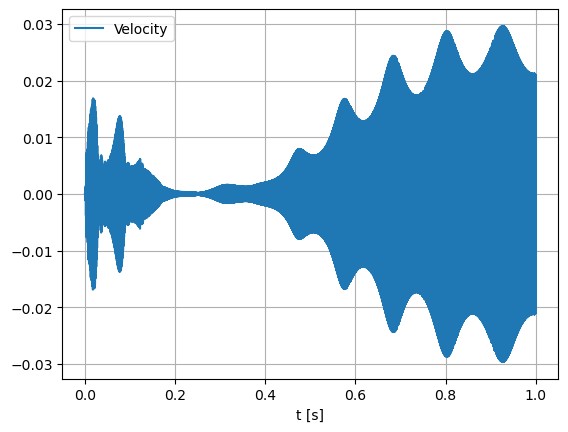

In [13]:

# %matplotlib widget
plt.figure()

# plt.plot(t, disp[10,:], '.-', label='Disp.')
plt.plot(t, veloc[10,:], '-', label='Velocity')
# plt.xlim([0, 0.05 ])
# plt.ylim(np.array([-1,1])*1e-3)

plt.xlabel("t [s]")
# plt.ylabel("displacement")
plt.legend()
plt.grid(True)


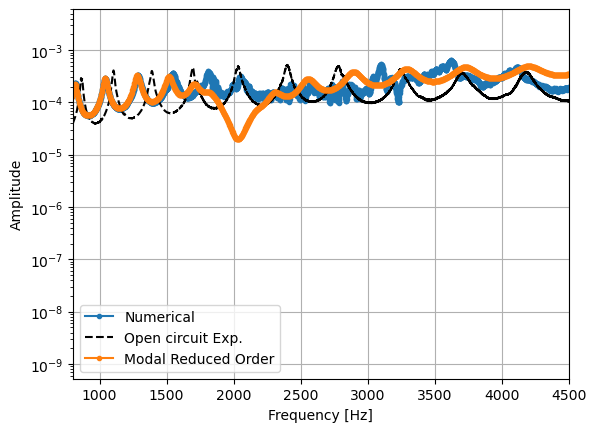

In [ ]:
npz_path_OC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\7\kc0_kp_sweep\OCSC\OC.npz".replace("\\", "/")
# npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\10\ki0_kc0_kpSweep\parametric_sweep.npz".replace("\\", "/")  
npz_path_linear =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\linear.npz".replace("\\", "/")  
# npz_path_OC =r"Z:\Nima\Synthetic_impedance\long_beam\ssdsl_dat\ssdsl_dat_Nov\11\OC.npz".replace("\\", "/")
data_OC = np.load(npz_path_OC)
data_linear = np.load(npz_path_linear)
frq_OC = data_OC['freq']			# (Nfreq,)
frf_data_OC = data_OC['frf_data']	# (Nfiles, Nfreq, Npoints)

frq_linear = data_linear['freq']            # (Nfreq,)
frf_data_linear = data_linear['frf_data']

# %matplotlib widget


# ----- Compute and plot spectrum -----
y = veloc                # velocity signal at x_eval index 10
Nt = len(t)
dt = t[1] - t[0]                  # sampling period
fs = 1/dt                         # sampling frequency

Y = np.fft.fft(y, axis=1)
X = np.fft.fft(v_exc(t))
freq = np.fft.fftfreq(Nt, d=dt)

# take only positive frequencies
idx = freq >= 0
freq = freq[idx]
Y = Y[:,idx]
X = X[idx]

plt.figure()
plt.semilogy(freq, np.mean(np.abs(Y), axis=0)/ np.abs(X), '.-', linewidth=1.5, label='Numerical')

# plt.semilogy(frq_linear, np.mean(frf_data_linear[:,:], axis=1), 'r--', label=' Exp.')
plt.semilogy(frq_OC, np.mean(frf_data_OC[:,:], axis=1), 'k--', label=f'Open circuit Exp.')
plt.semilogy(freq_modal, vel_mag, '.-', label='Modal Reduced Order'   )
plt.xlabel("Frequency [Hz]")
plt.xlim([800, 4500])

plt.ylabel("Amplitude")
# plt.title("Velocity Spectrum at x = x_eval[10]")
plt.grid(True)
plt.legend()


# kp Sweep

In [ ]:
K_c = 5e11
t_end = 1
K_i = 0.0
def run_sim(K_p):
	# --- local excitation function with this amplitude ---
	
	def v_exc(t, A_exc=50, f0=1000, f1=5000, t_end=t_end):
		return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
	x0 = np.zeros(2*N + 2*S)
	t_eval = np.arange(0, t_end, 1/f1/20)

	sol = solve_ivp(
		lambda t, x: odefun(t, x, v_exc=v_exc, K_c= K_c, K_p=K_p, K_i=K_i),
		(0, t_end),
		x0,
		t_eval=t_eval,
		method='RK45',
		rtol=1e-9,
		atol=1e-10
		)
	# reconstruct velocities on beam
	eta     = sol.y[0:N, :]
	eta_dot = sol.y[N:2*N, :]
	veloc   = np.zeros((len(x_eval), eta.shape[1]))
	for r in range(N):
		veloc += np.outer(mode_shape(r, x_eval), eta_dot[r,:])

	return sol.t, veloc

param_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]) * 125 # Amplitude sweep
param_list = np.arange(0.01, 0.8, 0.05) # K_p sweep
# A_list = np.array([0.05, 0.15, 0.25, 0.4]) * 125
# A_list = np.array([0.05, 0.4]) * 125

results = {
	"params": [],
	"param_name": "K_p",
	"t": None,
	"veloc": [],
	"freq": None,         # same for all sweeps
	"Y": [],              # velocity FFT
	"X": [],            # excitation FFT (same for all sweeps)
	"FRF": []             # FRF curves for each amplitude
}

for par in param_list:
	print(f"{results['param_name']} = {par} ...")

	# --- Run simulation ---
	t, veloc = run_sim(par)    # ensure run_sim returns v_in too
	results["params"].append(par)
	results["veloc"].append(veloc)
	# --- FFT parameters ---
	Nt = len(t)
	dt = t[1] - t[0]
	freq = np.fft.fftfreq(Nt, d=dt)
	# Velocity FFT
	Y = np.fft.fft(veloc, axis=1)
	results["Y"].append(Y)

	# Save time frequency (only once)
	if results["freq"] is None:
		results["freq"] = freq
		results["t"] = t
		
	# Excitation FFT X (only once)
	results["X"].append(np.fft.fft(v_exc(t, A_exc=A_exc)))

# extract freq, X for convenience
freq = results["freq"]
# keep only positive frequencies
idx = freq >= 0
freq_pos = freq[idx]


for i, Y in enumerate(results["Y"]):
	X = results["X"][i]
	X_pos = X[idx]
	Y_pos = Y[:, idx]
	FRF = np.mean(np.abs(Y), axis=0) / (np.abs(X))
	results["FRF"].append(FRF)

# overwrite positive frequencies for clarity
# results["freq"] = freq_pos



np.savez("./sim_dat/kc_sweep.npz", **results)
plt.figure(figsize=(9,5))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(results['Params'])))   # gradient from low A → high A
i = -1
for A, FRF in zip(results["Params"], results["FRF"]):
	i +=1
	# plt.semilogy(results["freq"], FRF, linewidth=1.2, label=f"A={A:.2f} V")
	plt.semilogy(results["freq"], FRF, color=colors[i], linewidth=3, label=f"{results['param_name']}={A/125:.2f} V")

plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF Magnitude")
plt.title(f"kc={K_c:.2e}, kp={K_p:0.3f}")
plt.xlim([500, 5000])
plt.grid(True)
plt.legend()
plt.show()


# Amplitude Sweep

In [ ]:
K_c = 6e9
K_p = 0.03
t_end = 1
K_i = 2100
def v_exc(t, A_exc=A_exc, f0=1000, f1=5000, t_end=t_end):
	return A_exc*np.sin(2*np.pi*(f0+ t*(f1-f0)/t_end) *t)
def run_sim(A_exc=50, K_c=K_c, K_p=K_p, K_i=K_i):
	# --- local excitation function with this amplitude ---
	

	x0 = np.zeros(2*N + 2*S)
	t_eval = np.arange(0, t_end, 1/f1/20)

	sol = solve_ivp(
		lambda t, x: odefun(t, x, v_exc=lambda t: v_exc(t, A_exc=A_exc), K_c= K_c, K_p=K_p, K_i=K_i),
		(0, t_end),
		x0,
		t_eval=t_eval,
		method='RK45',
		rtol=1e-9,
		atol=1e-10
		)
	# reconstruct velocities on beam
	eta     = sol.y[0:N, :]
	eta_dot = sol.y[N:2*N, :]
	veloc   = np.zeros((len(x_eval), eta.shape[1]))
	for r in range(N):
		veloc += np.outer(mode_shape(r, x_eval), eta_dot[r,:])

	return sol.t, veloc

param_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4]) * 125 # Amplitude sweep
# param_list = np.arange(0.01, 0.8, 0.05) # K_p sweep
# A_list = np.array([0.05, 0.15, 0.25, 0.4]) * 125
# param_list = np.array([0.05, 0.4]) * 125

results = {
	"params": [],
	"param_name": "Amp",
	"t": None,
	"veloc": [],
	"freq": None,         # same for all sweeps
	"Y": [],              # velocity FFT
	"X": [],            # excitation FFT (same for all sweeps)
	"FRF": []             # FRF curves for each amplitude
}

for par in param_list:
	print(f"{results['param_name']} = {par} ...")

	# --- Run simulation ---
	t, veloc = run_sim(A_exc=par)    # ensure run_sim returns v_in too
	results["params"].append(par)
	results["veloc"].append(veloc)
	# --- FFT parameters ---
	Nt = len(t)
	dt = t[1] - t[0]
	freq = np.fft.fftfreq(Nt, d=dt)
	# Velocity FFT
	Y = np.fft.fft(veloc, axis=1)
	results["Y"].append(Y)

	# Save time frequency (only once)
	if results["freq"] is None:
		results["freq"] = freq
		results["t"] = t
		
	# Excitation FFT X (only once)
	results["X"].append(np.fft.fft(v_exc(t, A_exc=par)))

# extract freq, X for convenience
freq = results["freq"]
# keep only positive frequencies
idx = freq >= 0
freq_pos = freq[idx]


for i, Y in enumerate(results["Y"]):
	X = results["X"][i]
	X_pos = X[idx]
	Y_pos = Y[:, idx]
	FRF = np.mean(np.abs(Y), axis=0) / (np.abs(X))
	results["FRF"].append(FRF)

# overwrite positive frequencies for clarity
# results["freq"] = freq_pos



Amp = 6.25 ...
Amp = 12.5 ...
Amp = 18.75 ...
Amp = 25.0 ...
Amp = 31.25 ...
Amp = 37.5 ...
Amp = 50.0 ...


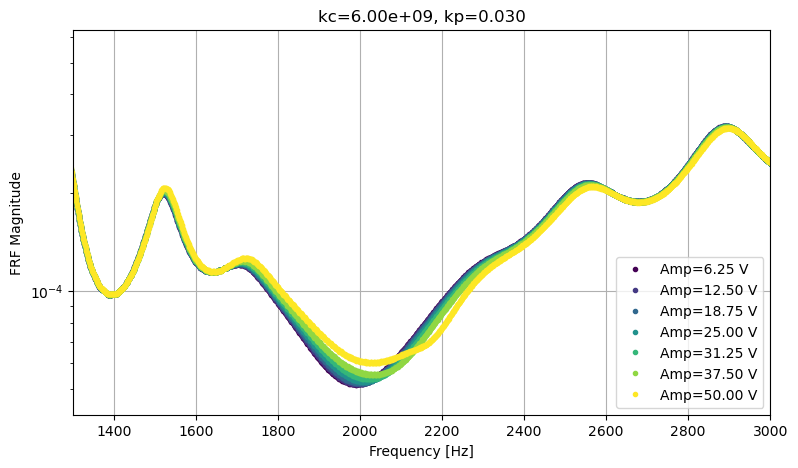

In [ ]:


np.savez("./sim_dat/amp_sweep.npz", **results)
plt.figure(figsize=(9,5))
cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(results['params'])))   # gradient from low A → high A
i = -1
for A, FRF in zip(results["params"], results["FRF"]):
	i +=1
	# plt.semilogy(results["freq"], FRF, linewidth=1.2, label=f"A={A:.2f} V")
	plt.semilogy(results["freq"], FRF, '.',color=colors[i], linewidth=3, label=f"{results['param_name']}={A:.2f} V")

plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF Magnitude")
plt.title(f"kc={K_c:.2e}, kp={K_p:0.3f}")
plt.xlim([1300, 3000])
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(9,5))
plt.semilogy(freq, np.abs(results["X"][1]), '.', linewidth=2, label='Excitation')
# plt.xlim([500, 10000])
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Excitation Spectrum")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
len(t)

In [ ]:
# Generate a chirp signal
t_end = 0.1
t = np.arange(0, t_end, 1/f1/20)
chirp_signal = v_exc(t, A_exc=A_exc, f0=f0, f1=2000, t_end=t_end)


# Compute and plot spectrum
Nt = len(t)
dt = t[1] - t[0]
freq = np.fft.fftfreq(Nt, d=dt)
X_chirp = np.fft.fft(chirp_signal)

# Take only positive frequencies
idx = freq >= 0
freq_pos = freq[idx]
X_pos = X_chirp[idx]

plt.figure(figsize=(12, 4))
plt.semilogy(freq, np.abs(X_chirp), '.-', linewidth=1.5)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title(f"Chirp Spectrum: {f0/1e3:.1f}–{f1/1e3:.1f} kHz")
plt.xlim([0, 12000])
plt.grid(True)
plt.show()

In [ ]:
%matplotlib widget
plt.figure()

plt.plot(t, v[30, :])
# plt.xlim([0, 1e-6 ])
# plt.ylim([-1,1])
plt.xlabel("t [s]")
plt.ylabel("eta_1(t)")
plt.grid(True)



In [ ]:

plt.figure()
plt.plot(t, v[20, :])
plt.xlabel("t [s]")
plt.ylabel("v_1(t) [V]")
plt.grid(True)
plt.show()

